# 00 - Data Setup & Verification

This notebook is run **once only** to:
1. Download the dataset from Roboflow (YOLOv8 format + COCO format)
2. Fix class names in data.yaml
3. Check that images and labels match
4. Show class distribution
5. Show sample images with bounding boxes

After running this, all experiment notebooks read from the local `datasets/` folder.

## Step 1 - Install what we need

In [4]:
%pip install -q roboflow pyyaml matplotlib Pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: c:\Users\MSI\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


## Step 2 - Setup paths and class names

In [5]:
import os

HOME = os.getcwd()
DATASET_DIR = os.path.join(HOME, 'datasets')

# Where each format will be saved
YOLO_PATH = os.path.join(DATASET_DIR, 'total-5')        # for YOLOv8 experiments
COCO_PATH = os.path.join(DATASET_DIR, 'total-5-coco')   # for RT-DETR experiments

# Roboflow project info
API_KEY = 'qPfRDo7AorEti39C5et4'
WORKSPACE = 'ensam-wyp9x'
PROJECT = 'total-jcwvt'
VERSION = 5

# Our two classes
CLASS_NAMES = {
    0: 'marked-speed-bump',       # painted, clearly visible
    1: 'non-marked-speed-bump'    # unpainted, hard to see
}

# Create datasets folder if it doesn't exist
os.makedirs(DATASET_DIR, exist_ok=True)

print('Home:', HOME)
print('Datasets folder:', DATASET_DIR)

Home: e:\Ventoy\bump detection project
Datasets folder: e:\Ventoy\bump detection project\datasets


## Step 3 - Download dataset

We download **two copies** of the same dataset:
- **YOLOv8 format** → for Experiment 1 (YOLOv8) and Experiment 3 (Hybrid)
- **COCO format** → for Experiment 2 (RT-DETR)

If already downloaded, it will skip.

In [6]:
from roboflow import Roboflow

rf = Roboflow(api_key=API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT)
version = project.version(VERSION)

# Download YOLOv8 format
yolo_train_dir = os.path.join(YOLO_PATH, 'train', 'images')
if os.path.exists(yolo_train_dir) and len(os.listdir(yolo_train_dir)) > 0:
    print('YOLOv8 format already downloaded, skipping.')
else:
    print('Downloading YOLOv8 format...')
    version.download('yolov8', location=YOLO_PATH)
    print('Done!')

# Download COCO format
coco_train_dir = os.path.join(COCO_PATH, 'train')
if os.path.exists(coco_train_dir) and len(os.listdir(coco_train_dir)) > 0:
    print('COCO format already downloaded, skipping.')
else:
    print('Downloading COCO format...')
    version.download('coco', location=COCO_PATH)
    print('Done!')

loading Roboflow workspace...
loading Roboflow project...
YOLOv8 format already downloaded, skipping.
COCO format already downloaded, skipping.


## Step 4 - Fix class names in data.yaml

Roboflow named the classes `'0'` and `'1'` which is confusing.
We change them to `'marked-speed-bump'` and `'non-marked-speed-bump'`.
We also set absolute paths so YOLO doesn't get confused about file locations.

In [7]:
import yaml

yaml_path = os.path.join(YOLO_PATH, 'data.yaml')

# Read the file
with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)

print('BEFORE:')
print('  Class names:', config['names'])

# Fix the class names
config['names'] = ['marked-speed-bump', 'non-marked-speed-bump']

# Fix the paths (use absolute paths to avoid errors)
config['train'] = os.path.join(YOLO_PATH, 'train', 'images')
config['val']   = os.path.join(YOLO_PATH, 'valid', 'images')
config['test']  = os.path.join(YOLO_PATH, 'test', 'images')

# Save the fixed file
with open(yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print('\nAFTER:')
print('  Class names:', config['names'])
print('  Train path:', config['train'])
print('  Val path:  ', config['val'])
print('  Test path: ', config['test'])
print('\ndata.yaml fixed!')

BEFORE:
  Class names: ['0', '1']

AFTER:
  Class names: ['marked-speed-bump', 'non-marked-speed-bump']
  Train path: e:\Ventoy\bump detection project\datasets\total-5\train\images
  Val path:   e:\Ventoy\bump detection project\datasets\total-5\valid\images
  Test path:  e:\Ventoy\bump detection project\datasets\total-5\test\images

data.yaml fixed!


## Step 5 - Check that every image has a label file

Each image (`.jpg`) should have a matching label (`.txt`) with the same name.

In [8]:
print('Checking annotations...\n')

for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(YOLO_PATH, split, 'images')
    lbl_dir = os.path.join(YOLO_PATH, split, 'labels')

    # Get just the file names without extensions
    image_names = []
    for f in os.listdir(img_dir):
        if f.endswith('.jpg') or f.endswith('.jpeg') or f.endswith('.png'):
            name_without_ext = f.rsplit('.', 1)[0]
            image_names.append(name_without_ext)

    label_names = []
    for f in os.listdir(lbl_dir):
        if f.endswith('.txt'):
            name_without_ext = f.rsplit('.', 1)[0]
            label_names.append(name_without_ext)

    # Check for mismatches
    images_set = set(image_names)
    labels_set = set(label_names)

    missing_labels = images_set - labels_set
    extra_labels = labels_set - images_set

    if len(missing_labels) == 0 and len(extra_labels) == 0:
        print(f'  {split.upper()}: {len(image_names)} images, {len(label_names)} labels - ALL MATCHED')
    else:
        print(f'  {split.upper()}: WARNING!')
        if missing_labels:
            print(f'    {len(missing_labels)} images have no label file')
        if extra_labels:
            print(f'    {len(extra_labels)} labels have no image file')

Checking annotations...

  TRAIN: 628 images, 628 labels - ALL MATCHED
  VALID: 181 images, 181 labels - ALL MATCHED
  TEST: 75 images, 75 labels - ALL MATCHED


## Step 6 - Count annotations per class

How many marked vs non-marked speed bumps do we have?

TRAIN:
  marked-speed-bump:     666
  non-marked-speed-bump: 39

VALID:
  marked-speed-bump:     198
  non-marked-speed-bump: 8

TEST:
  marked-speed-bump:     77
  non-marked-speed-bump: 4



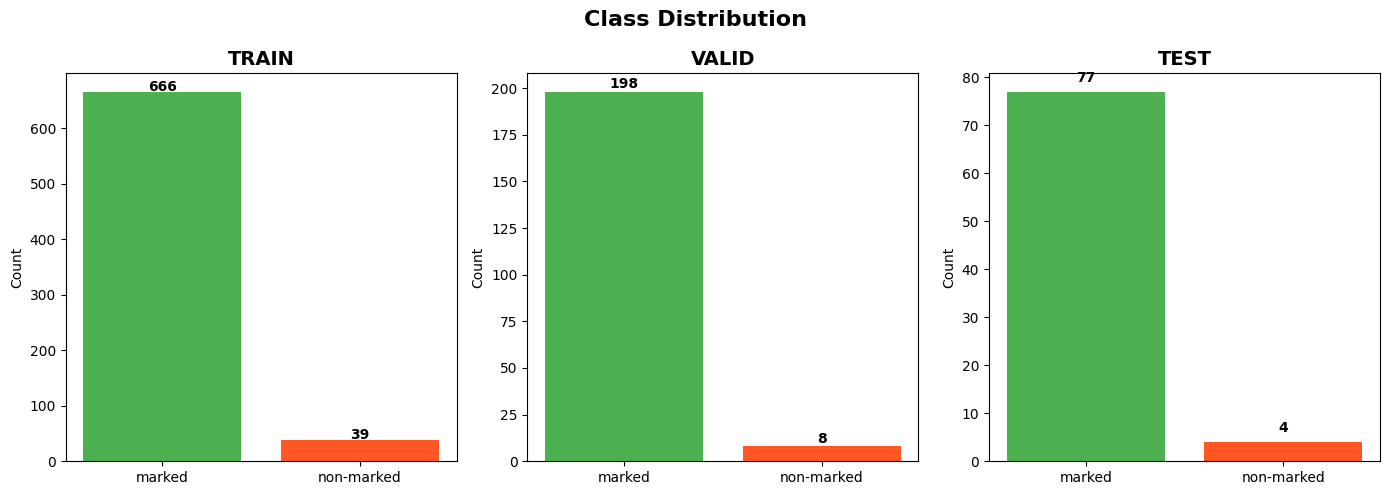

In [9]:
import matplotlib.pyplot as plt

# Count annotations in each split
counts = {}  # will store: {'train': {0: 666, 1: 39}, ...}

for split in ['train', 'valid', 'test']:
    lbl_dir = os.path.join(YOLO_PATH, split, 'labels')
    counts[split] = {0: 0, 1: 0}

    for filename in os.listdir(lbl_dir):
        if not filename.endswith('.txt'):
            continue

        filepath = os.path.join(lbl_dir, filename)
        with open(filepath, 'r') as f:
            for line in f:
                line = line.strip()
                if line:
                    class_id = int(line.split()[0])
                    counts[split][class_id] = counts[split].get(class_id, 0) + 1

    # Print results
    print(f'{split.upper()}:')
    print(f'  marked-speed-bump:     {counts[split][0]}')
    print(f'  non-marked-speed-bump: {counts[split][1]}')
    print()

# --- Draw a simple bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, split in enumerate(['train', 'valid', 'test']):
    marked = counts[split][0]
    non_marked = counts[split][1]

    bars = axes[i].bar(['marked', 'non-marked'], [marked, non_marked],
                       color=['#4CAF50', '#FF5722'])
    axes[i].set_title(split.upper(), fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Count')

    # Put the numbers on top of each bar
    axes[i].text(0, marked + 2, str(marked), ha='center', fontweight='bold')
    axes[i].text(1, non_marked + 2, str(non_marked), ha='center', fontweight='bold')

plt.suptitle('Class Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(HOME, 'class_distribution.png'), dpi=150)
plt.show()

## Step 7 - Check class imbalance

In [10]:
# Add up totals across all splits
total_marked = counts['train'][0] + counts['valid'][0] + counts['test'][0]
total_non_marked = counts['train'][1] + counts['valid'][1] + counts['test'][1]

if total_non_marked > 0:
    ratio = total_marked / total_non_marked
else:
    ratio = float('inf')

print('CLASS IMBALANCE REPORT')
print('=' * 40)
print(f'Total marked:     {total_marked}')
print(f'Total non-marked: {total_non_marked}')
print(f'Ratio:            {ratio:.1f} : 1')
print()

if ratio > 10:
    print('SEVERE IMBALANCE!')
    print('The model will struggle with non-marked bumps.')
    print('We should monitor per-class mAP separately.')
elif ratio > 5:
    print('MODERATE IMBALANCE - keep an eye on per-class metrics.')
else:
    print('Class balance looks acceptable.')

CLASS IMBALANCE REPORT
Total marked:     941
Total non-marked: 51
Ratio:            18.5 : 1

SEVERE IMBALANCE!
The model will struggle with non-marked bumps.
We should monitor per-class mAP separately.


## Step 8 - Show sample images with bounding boxes

Let's visually check that the labels are correct.

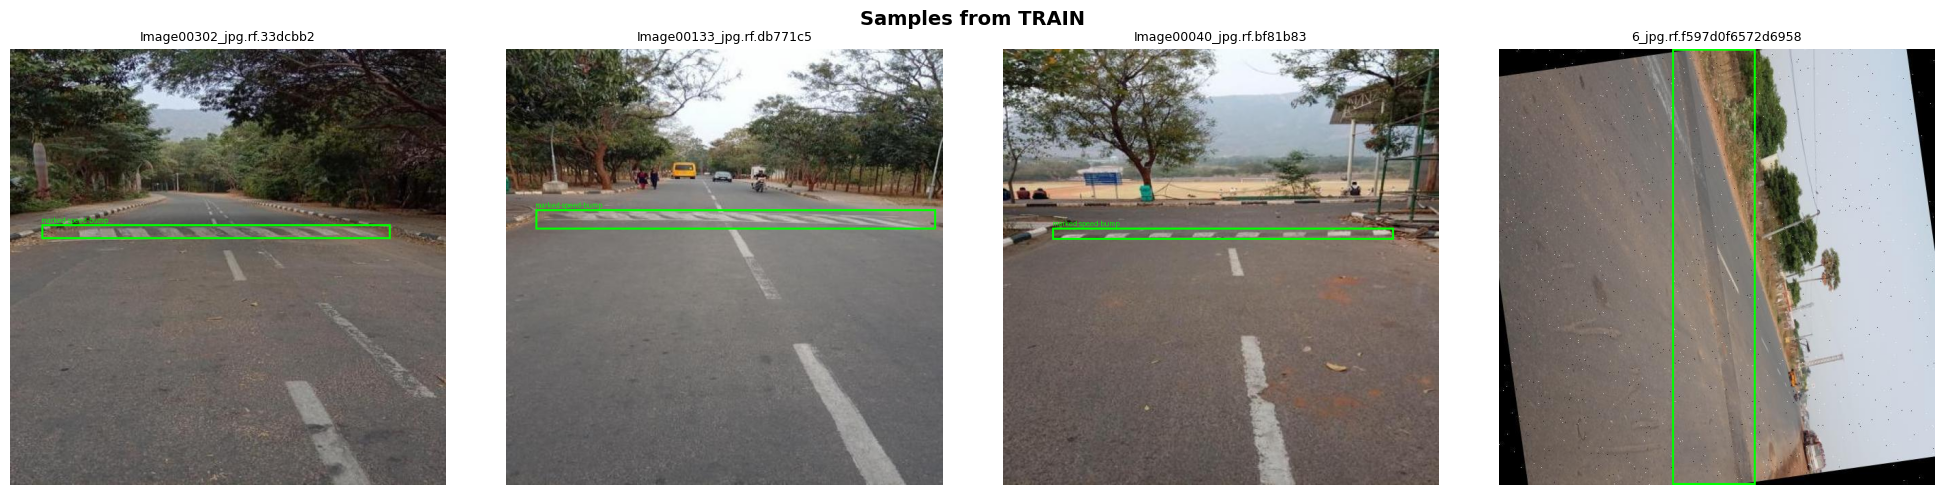

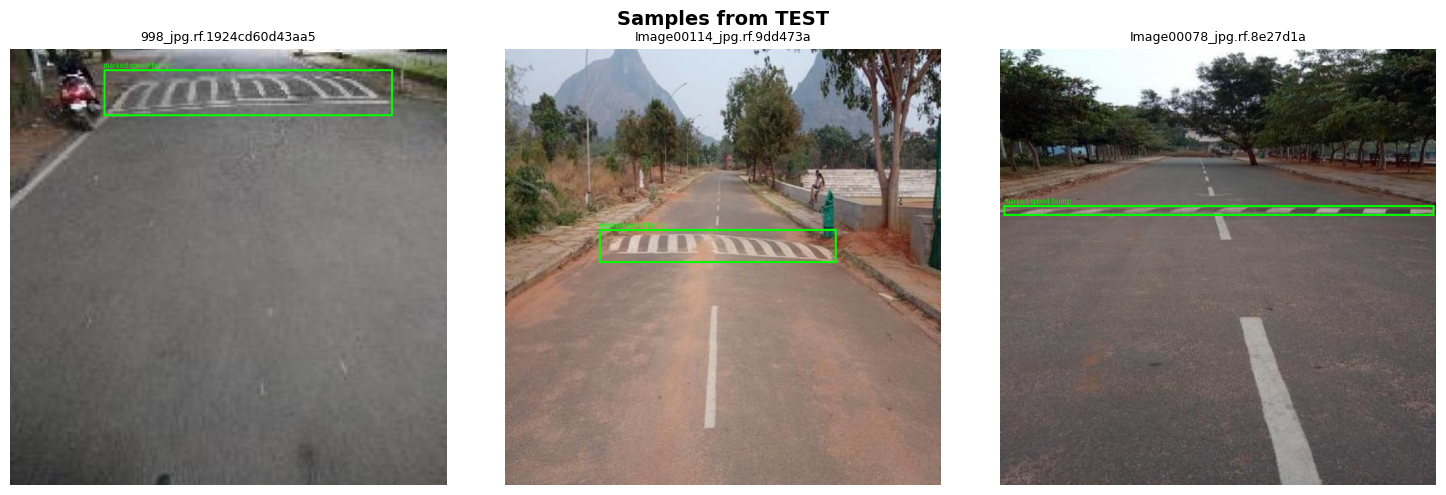

In [17]:
from PIL import Image, ImageDraw, ImageFont
import random
import matplotlib.pyplot as plt

def show_samples(split='train', how_many=4):
    """Show random images with their bounding boxes drawn on."""
    img_dir = os.path.join(YOLO_PATH, split, 'images')
    lbl_dir = os.path.join(YOLO_PATH, split, 'labels')

    # Get list of images
    all_images = [f for f in os.listdir(img_dir)
                  if f.endswith('.jpg') or f.endswith('.png')]
    chosen = random.sample(all_images, min(how_many, len(all_images)))

    fig, axes = plt.subplots(1, len(chosen), figsize=(5 * len(chosen), 5))
    if len(chosen) == 1:
        axes = [axes]

    for ax, img_name in zip(axes, chosen):
        # Open image
        img_path = os.path.join(img_dir, img_name)
        img = Image.open(img_path)
        draw = ImageDraw.Draw(img)
        w, h = img.size

        # Read label file
        label_name = img_name.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(lbl_dir, label_name)

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue

                    cls_id = int(parts[0])
                    cx = float(parts[1]) * w   # center x
                    cy = float(parts[2]) * h   # center y
                    bw = float(parts[3]) * w   # box width
                    bh = float(parts[4]) * h   # box height

                    # Convert center format to corner format
                    x1 = cx - bw / 2
                    y1 = cy - bh / 2
                    x2 = cx + bw / 2
                    y2 = cy + bh / 2

                    # Green for marked, red for non-marked
                    color = 'lime' if cls_id == 0 else 'red'
                    label = CLASS_NAMES.get(cls_id, str(cls_id))

                    draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
                    draw.text((x1, y1 - 12), label, fill=color)

        ax.imshow(img)
        ax.set_title(img_name[:25], fontsize=9)
        ax.axis('off')

    plt.suptitle(f'Samples from {split.upper()}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Show some samples
show_samples('train', 4)
show_samples('test', 3)

## Step 9 - Verify COCO format too

Quick check that the COCO JSON files are readable.

In [12]:
import json

print('COCO Format Check:')
print('=' * 40)

for split in ['train', 'valid', 'test']:
    json_path = os.path.join(COCO_PATH, split, '_annotations.coco.json')

    with open(json_path, 'r') as f:
        data = json.load(f)

    num_images = len(data['images'])
    num_annotations = len(data['annotations'])
    categories = {c['id']: c['name'] for c in data['categories']}

    print(f'\n{split.upper()}:')
    print(f'  Images: {num_images}')
    print(f'  Annotations: {num_annotations}')
    print(f'  Categories: {categories}')

print('\nCOCO data looks good!')

COCO Format Check:

TRAIN:
  Images: 628
  Annotations: 705
  Categories: {0: 'pothole-speedbump', 1: '0', 2: '1'}

VALID:
  Images: 181
  Annotations: 206
  Categories: {0: 'pothole-speedbump', 1: '0', 2: '1'}

TEST:
  Images: 75
  Annotations: 81
  Categories: {0: 'pothole-speedbump', 1: '0', 2: '1'}

COCO data looks good!


## Done!

You now have:

| What | Where | Used by |
|------|-------|---------|
| YOLOv8 data | `datasets/total-5/` | Experiment 1 & 3 |
| COCO data | `datasets/total-5-coco/` | Experiment 2 |
| Fixed data.yaml | `datasets/total-5/data.yaml` | Experiment 1 & 3 |

**Next:** Open `01_Experiment_YOLOv8.ipynb` to train the baseline model.

**Do NOT re-run this notebook** unless you deleted the data.